# RNN (순환 신경망)
- 이전의 시점의 정보를 현재 시점에 계산에 반영하는 구조

- 첫 번재 입력이 들어왔을떄
    - 초기의 상태(h_0 = 0)와 입력에 대한 상태 (h_1)로 계산
- 두 번째 입력이 들어왔을때
    - 이전의 상태 (h_1)과 결합해서 계산 (h_2)
- 반복 작업이 완료가 되었을때
    - 마지막 상태 (h_T) 생성

- 매개변수
    -input_size
        - 각 시점에서 입려그이 피쳐의 개수
    - hidden_size
        - 은닉층(or 출력)의 크기
    - num_layers
        - 기본값 : 1
        - RNN 층의 개수 (층이 깊을수록 복잡한 패턴이 생성)
        - 개수가 늘어날수록 시간이 증가하고 과적합의 위험성이 존재
        - 1~3 정도 사용을 할때 1부터 개수를 1씩 늘려가면서 사용
    - nonlinearity
        - 기본값 : 'tanh'
        - 비선형 활성화 함수를 선택
    - bias
        - 기본값 : True
        - 각 가중치에 편향 항을 추가 여부
    - batch_first
        - 기본값 : False
        - 입력 텐서 첫 차원이 배치인지 여부
    - dropout
        - 기본값 : 0.0
        - 층 사이에 드랍아웃의 적용 비율 -> 층이 2개 이상에 사용
    - bidirectional
        - 기본값 : False
        - 양방향 RNN을 사용하지 여부 (순방향이 기본, 역방향을 사용할지 지정)

- 매개변수의 유의점
    - hidden_size
        - 너무 적은 경우라면 정보가 부족, 너무 큰 경우에는 과적합
        - 일반적으로는 32~128
    - num_layers
        - 시간의 복잡도에 따라 1~3정도 사용
        - 1부터 테스트를 돌려서 교차 검증
    - nolinearity
        - 'tanh'이 기본값이 'relu'로 변경하게 되면 시간은 감소할 수 있지만 불안정
    - dropout
        - 층이 2개 이상인 경우 사용
        - 과적합 방지를 위해 0.2~0.5사용 (권장)

In [48]:
# RNN 기본형
# 샘플 데이터를 생성해서 코드 작성
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [49]:
# 랜덤 일관성 설정
np.random.seed(42)
torch.manual_seed(42)

In [50]:
# 사인 그래프를 생성 + 노이즈

idx = torch.arange(3000).float()
data = torch.sin(2*math.pi*0.02 * idx) + 0.05 * torch.rand(3000)

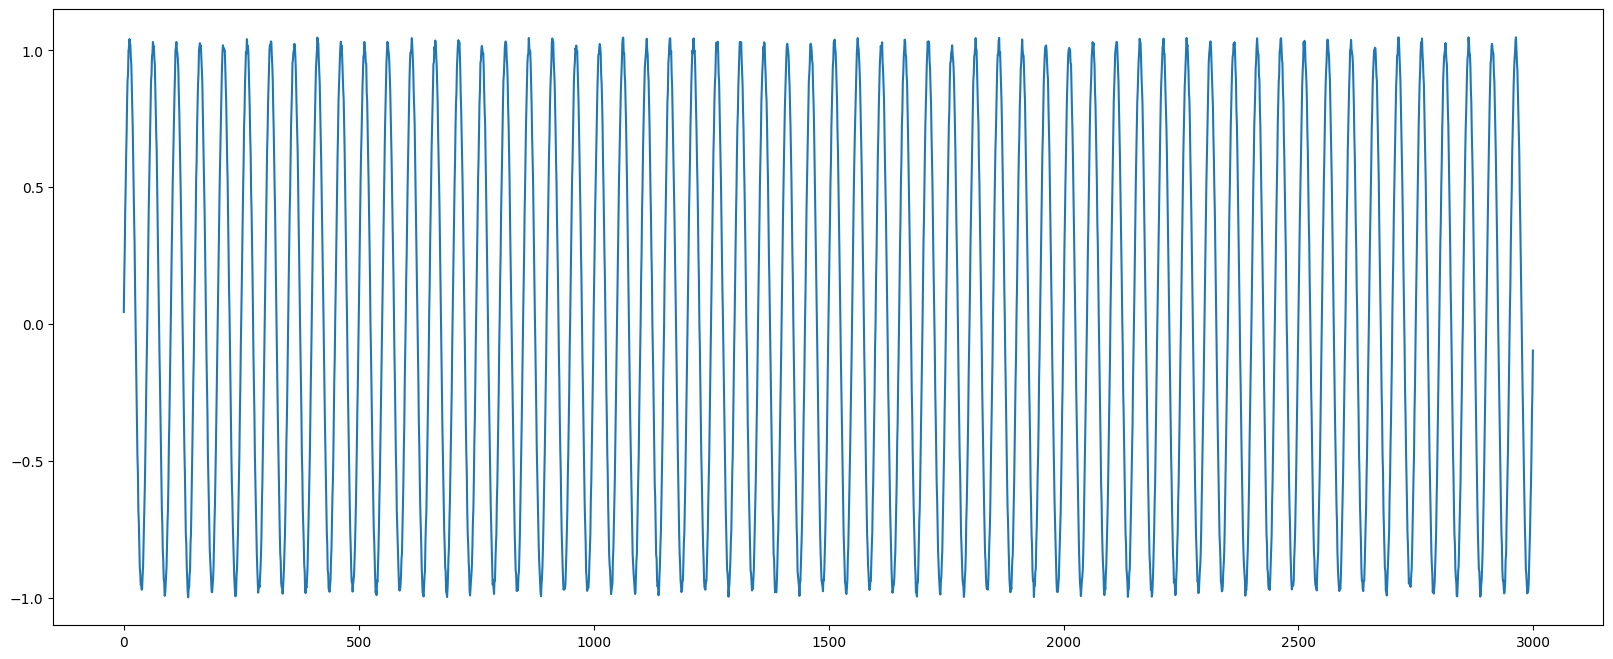

In [51]:
plt.figure(figsize=(20, 8))
plt.plot(idx, data)
plt.show()

In [52]:
# 연속성이 있는 시계열데이터를 기준으로 train, test를 8:2의 비율로 나눠준다.
# 앞부분 80%, 뒤부분 20%
# 저ㅓㄴ체 데이터의 길이에서 0.8을 곱한 idx의 값이 데이터의 경계
split_idx = int(len(data) * 0.8)
train_data = data[: split_idx]       # 학습 데이터(구간)
test_data = data[split_idx :]        # 평가 데이터(구간)

In [53]:
# train와 test를 스케일링
scaler = StandardScaler()

train_data = scaler.fit_transform(train_data.reshape(-1, 1))
test_data = scaler.transform(test_data.reshape(-1, 1))

In [54]:
# data들을 torch에서 사용하기 위한 tensor의 형태로 변환 (2차원의 데이터를 1차원의 데이터로 변환)
train_data = torch.tensor(train_data.squeeze(-1), dtype = torch.float32)
test_data = torch.tensor(test_data.squeeze(-1), dtype = torch.float32)

In [55]:
class WindowDatatset(Dataset):
    # 단변량 시계열 데이터에서 입력 값, 정받ㅂ 값을 만드는 Dataset
    def __init__(self, _data, _window):
        # _data : (N, ) 형태가 1차원 tensor 데이터
        # _window : 과거의 몇개의 데이터를 볼 것인가? (구간 설정)
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수는 학습 데이터의 개수는 data의 전체 길이에서 -1
        # 입력 데이터는 전체 길이 - 윈도우
        self.n = len(_data) - _window
    
    # __len__(), __getitem__() 두개의 특수 합수들은 DataLoader에서 자동으로 호출해서 사용이 되는 부분
    def __len__(self):
        return max(self.n, 0)
    
    def __getitem__(self, idx):
        # 변환
        # x -> 입력 데이터 (윈도우의 구간을 나타내는 구간) --> 문제
        # y -> 입력 데이터 다음 행의 데이터 --> 정답
        x = self.data[idx : idx+self.window].unsqueeze(-1)  # (window,) -> (window, 1)
        y = self.data[idx + self.window].unsqueeze(-1)
        return x, y

In [56]:
# class 생성
# 구간 설정 값
window = 50
train_ds = WindowDatatset(train_data, window)
val_ds = WindowDatatset(test_data, window)

In [57]:
# DataLoader : 학습 데이터를 구간 별로 뽑아서 새로운 리스트 형 데이터를 생성
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
val_dl = DataLoader(val_ds, shuffle=False, drop_last=False, batch_size=256)

## DataLoader
- 파이토치에서 Dataset들을 효율적으로 배치 단위로 꺼내주는 반복자
- 반복학습 루프에 맞는 형태의 데이터셋을 공급해주는 역할
- batch_size(배치 생성) -> Dataset들을 모아서 텐서의 형태로 묶어줌
- shuffle -> 에폭마다 데이터의 순서를 랜덤하게 변경
- drop_last -> window에 맞게 구간을 나누고 마지막 구간의 데이터의 개수가 작은 경우 해당 배치를 제거
- pin_memory -> GPU 사용 시 True로 변경하면 CPU -> GPU 전송이 빨라짐

In [58]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, foward()함수
    
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1,
        nonlinearity = 'tanh',
        dropout = 0.0,
        bidirectional = False,
        batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size= input_size,
            hidden_size= hidden_size,
            num_layers= num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )
        #self.head = nn.Linear(hidden_size, 1)      # 1차원 스칼라 회귀
        # bidirectional의 값이 False인 경우에는 hidden_size을 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Linear(out_features, 1)
        
    def forward(self, x):
        # out -> 모든 시점에서는 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값
        # -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(x)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

In [59]:
rnn_model = RNNReg(
    input_size=1, hidden_size=64
)
rnn_model

RNNReg(
  (rnn): RNN(1, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [60]:
# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
# loss의 미분 폭주 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
def evaliate_mse(dataloader):
    rnn_model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.float()
            y = y.float()
            yhat = rnn_model(x)
            loss = criterion(yhat, y)
            # 총 손실
            total_loss += loss.item() * y.size(0)
            # loss.itme() : 손실의 평균
            # size(0) : 개수
            total_n += y.size(0)
    return total_loss / max(total_n, 1)

In [61]:
# 반복 학습 루프

# 학습 데이터의 loss들 검증 데이터의 loss들을 저장 -> 시각화
train_history = []
val_history = []

for epoch in range(20):
    rnn_model.train()
    running=0.0
    n_seen = 0
    
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        
        optimizer.zero_grad()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(rnn_model.parameters(), max_grad_norm)
        
        optimizer.step()
        
        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / max(n_seen, 1)
    val_mse = evaliate_mse(val_dl)
    train_history.append(train_mse)
    val_history.append(val_mse)
    print(f"epoch : {epoch + 1}, train_mse : {round(train_mse, 3)}, val_mse : {round(val_mse, 5)}")

epoch : 1, train_mse : 0.352, val_mse : 0.01107
epoch : 2, train_mse : 0.007, val_mse : 0.00386
epoch : 3, train_mse : 0.003, val_mse : 0.00258
epoch : 4, train_mse : 0.002, val_mse : 0.00215
epoch : 5, train_mse : 0.002, val_mse : 0.00195
epoch : 6, train_mse : 0.002, val_mse : 0.00144
epoch : 7, train_mse : 0.001, val_mse : 0.00139
epoch : 8, train_mse : 0.001, val_mse : 0.00134
epoch : 9, train_mse : 0.001, val_mse : 0.00126
epoch : 10, train_mse : 0.001, val_mse : 0.00122
epoch : 11, train_mse : 0.001, val_mse : 0.00093
epoch : 12, train_mse : 0.001, val_mse : 0.00076
epoch : 13, train_mse : 0.001, val_mse : 0.00094
epoch : 14, train_mse : 0.001, val_mse : 0.00084
epoch : 15, train_mse : 0.001, val_mse : 0.00087
epoch : 16, train_mse : 0.001, val_mse : 0.00096
epoch : 17, train_mse : 0.001, val_mse : 0.00074
epoch : 18, train_mse : 0.001, val_mse : 0.00084
epoch : 19, train_mse : 0.001, val_mse : 0.00072
epoch : 20, train_mse : 0.001, val_mse : 0.00068


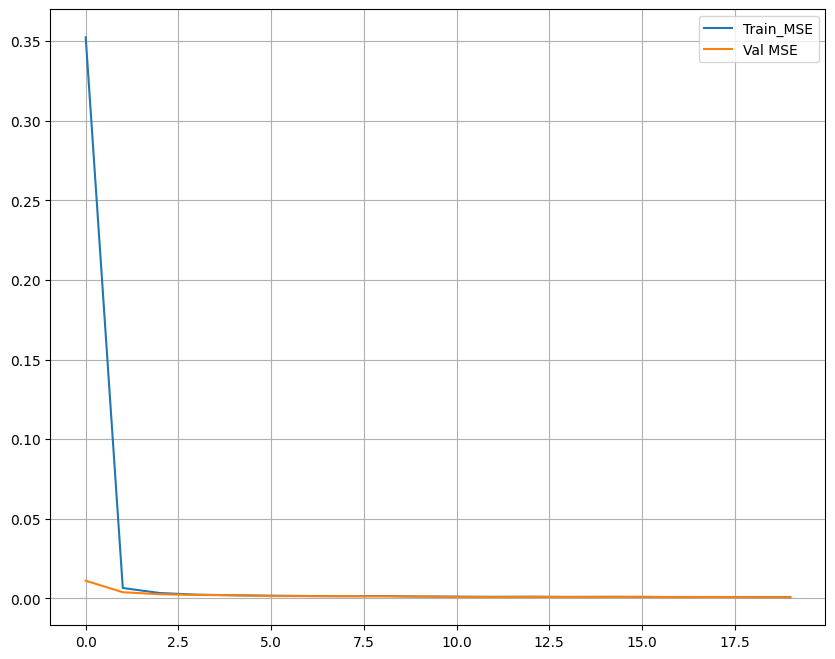

In [62]:
# MSE의 곡선을 그래프로 확인
plt.figure(figsize=(10, 8))
plt.plot(train_history, label='Train_MSE')
plt.plot(val_history, label='Val MSE')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
# 검증 구간의 데이터와 실제의 예측데이터를 비교 시각화
rnn_model.eval()
preds = []
trues = []

with torch.no_grad():
    for x, y in val_dl:
        x = x.float()
        y = y.float()
        yhat = rnn_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())

In [73]:
preds

[tensor([[ 0.0116],
         [ 0.1841],
         [ 0.3580],
         [ 0.5388],
         [ 0.7014],
         [ 0.8387],
         [ 0.9529],
         [ 1.0709],
         [ 1.1962],
         [ 1.2983],
         [ 1.3613],
         [ 1.3905],
         [ 1.4128],
         [ 1.4075],
         [ 1.3940],
         [ 1.3515],
         [ 1.2752],
         [ 1.1832],
         [ 1.0822],
         [ 0.9555],
         [ 0.8194],
         [ 0.6522],
         [ 0.4843],
         [ 0.3061],
         [ 0.1417],
         [-0.0213],
         [-0.2041],
         [-0.3771],
         [-0.5251],
         [-0.6736],
         [-0.8306],
         [-0.9860],
         [-1.1157],
         [-1.2156],
         [-1.2886],
         [-1.3563],
         [-1.4055],
         [-1.4347],
         [-1.4271],
         [-1.3842],
         [-1.3264],
         [-1.2638],
         [-1.1825],
         [-1.0718],
         [-0.9591],
         [-0.8375],
         [-0.6987],
         [-0.5352],
         [-0.3514],
         [-0.1620],


In [74]:
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

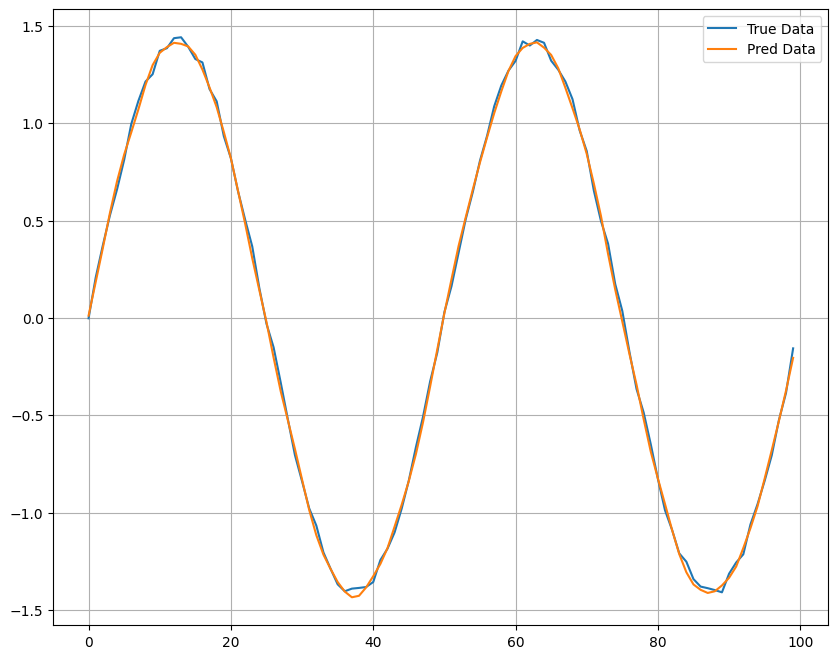

In [76]:
plt.figure(figsize=(10, 8))
plt.plot(trues[:100], label='True Data')
plt.plot(preds[:100], label='Pred Data')
plt.legend()
plt.grid(True)
plt.show()